# kSZ Non-Gaussianity — GRIZZLY (1D Radiative Transfer)

Same analysis as `open_nikos.ipynb` but using GRIZZLY simulations (Ghara et al.)
which use **1D radiative transfer** rather than 21cmFAST's excursion-set formalism.

**Why this matters:** 21cmFAST produces approximately spherical bubbles by construction.
GRIZZLY resolves I-front propagation with 1D RT, giving more realistic bubble morphology
(irregular shapes, shadows, partial ionization). This should produce **more non-Gaussian**
kSZ maps if bubble structure is the dominant source of non-Gaussianity.

**Data:** 51 coeval boxes at z = 6.05–12.05, 600³ grid, 500 Mpc/h box.
We stitch these into a pseudo-lightcone for LOS integration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from powerbox import get_power
from astropy.cosmology import FlatLambdaCDM
from astropy import constants
import gc
import random

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
import jax.numpy as jnp
import BFast

In [2]:
# ── GRIZZLY simulation parameters ──
DATA_DIR = "../data_grizzly/"
N_CELL = 600
BOX_MPC_H = 500.0   # Mpc/h
H_LITTLE = 0.7
BOX_LEN = BOX_MPC_H / H_LITTLE  # ~714.3 comoving Mpc
OMEGA_M = 0.27
OMEGA_L = 0.73
OMEGA_B = 0.045
NC_PM = 13824  # PM grid for velocity conversion

# Crop to avoid boundary effects (central 540 cells)
CROP = slice(30, 570)
N_CROP = 540
BOX_CROP = BOX_LEN * N_CROP / N_CELL

# GRIZZLY cosmology
cosmo_griz = FlatLambdaCDM(H0=70.0, Om0=OMEGA_M, Ob0=OMEGA_B)

# xHI filename pattern
XHI_PATTERN = "zeta0.389fesc0.389_Mmin0.120E+10_MminX0.120E+10_fx0.100E+03_sed3_al1.200xhi.bin"

print(f"Box: {BOX_MPC_H} Mpc/h = {BOX_LEN:.1f} Mpc, {N_CELL}³ cells")
print(f"Crop: {N_CROP}³ cells, {BOX_CROP:.1f} Mpc")

Box: 500.0 Mpc/h = 714.3 Mpc, 600³ cells
Crop: 540³ cells, 642.9 Mpc


In [3]:
# ── Data readers (from ksz_reconstruction/functions/generate_all_plots.py) ──

def read_den(filename, nx=N_CELL, ny=N_CELL, nz=N_CELL, endian="<"):
    dt_f4 = np.dtype(endian + "f4")
    with open(filename, 'rb') as f:
        f.seek(12)
        data = np.fromfile(f, dtype=dt_f4, count=nx*ny*nz)
    return data.reshape((nx, ny, nz), order='F')

def read_xhi(filename, nx=N_CELL, ny=N_CELL, nz=N_CELL):
    with open(filename, 'rb') as f:
        data = np.fromfile(f, dtype=np.float32, count=nx*ny*nz)
    return data.reshape((nx, ny, nz), order='F')

def read_vel(z, den, filename, n_cell=N_CELL, box=BOX_MPC_H, nc=NC_PM,
             hlittle=H_LITTLE, endian="<"):
    Megaparsec = 3.08568025e24
    omega_m = OMEGA_M
    Ho = hlittle * 3.2407e-18
    dt_f4 = np.dtype(endian + "f4")
    with open(filename, 'rb') as f:
        f.seek(12)
        arrv3 = np.fromfile(f, dtype=dt_f4, count=3 * n_cell**3)
    arrv3 = arrv3.reshape((3, n_cell, n_cell, n_cell), order="F").astype(np.float32, copy=False)
    len_unit = box * Megaparsec / hlittle / (1.0 + z) / float(nc)
    tau_t = 2.0 / 3.0 / np.sqrt(omega_m * Ho * Ho) / (1.0 + z)**2
    vel_unit = len_unit / tau_t
    arrv3 *= np.float32(vel_unit * 8.0)  # cm/s
    eps = np.float32(1e-12)
    den_safe = np.where(den > eps, den, eps)
    vz = (arrv3[2] / den_safe).astype(np.float32, copy=False)
    del arrv3
    return vz  # cm/s

print("Data readers defined.")

Data readers defined.


In [4]:
# ── Find available redshifts and measure mean xHI ──
import glob, os, re

den_files = sorted(glob.glob(DATA_DIR + "*n_all.dat"))
redshifts_all = np.array([float(re.search(r'([\d.]+)n_all', f).group(1)) for f in den_files])
redshifts_all = np.sort(redshifts_all)

print(f"Found {len(redshifts_all)} snapshots: z = {redshifts_all.min():.3f} – {redshifts_all.max():.3f}")

# Measure mean xHI at each redshift
mean_xHI_all = []
for z in redshifts_all:
    xhi_file = DATA_DIR + f"{z:.3f}{XHI_PATTERN}"
    if os.path.exists(xhi_file):
        xhi = read_xhi(xhi_file)
        mean_xHI_all.append(xhi.mean())
        del xhi
    else:
        mean_xHI_all.append(np.nan)
mean_xHI_all = np.array(mean_xHI_all)

print("\nz       | <xHI>")
for z, x in zip(redshifts_all, mean_xHI_all):
    print(f"  {z:.3f} | {x:.4f}")

Found 51 snapshots: z = 6.056 – 12.048

z       | <xHI>
  6.056 | 0.0000
  6.113 | 0.0152
  6.172 | 0.0617
  6.231 | 0.1091
  6.292 | 0.1546
  6.354 | 0.1996
  6.418 | 0.2388
  6.483 | 0.2807
  6.549 | 0.3187
  6.617 | 0.3548
  6.686 | 0.3932
  6.757 | 0.4252
  6.830 | 0.4598
  6.905 | 0.4894
  6.981 | 0.5210
  7.059 | 0.5494
  7.139 | 0.5787
  7.221 | 0.6056
  7.305 | 0.6291
  7.391 | 0.6543
  7.480 | 0.6776
  7.570 | 0.6993
  7.664 | 0.7194
  7.760 | 0.7407
  7.859 | 0.7593
  7.960 | 0.7787
  8.064 | 0.7952
  8.172 | 0.8106
  8.283 | 0.8273
  8.397 | 0.8425
  8.515 | 0.8558
  8.636 | 0.8699
  8.762 | 0.8823
  8.892 | 0.8937
  9.026 | 0.9040
  9.164 | 0.9148
  9.308 | 0.9239
  9.457 | 0.9329
  9.611 | 0.9409
  9.771 | 0.9487
  9.938 | 0.9555
  10.110 | 0.9612
  10.290 | 0.9670
  10.478 | 0.9722
  10.673 | 0.9765
  10.877 | 0.9807
  11.090 | 0.9840
  11.313 | 0.9871
  11.546 | 0.9897
  11.791 | 0.9918
  12.048 | 0.9938


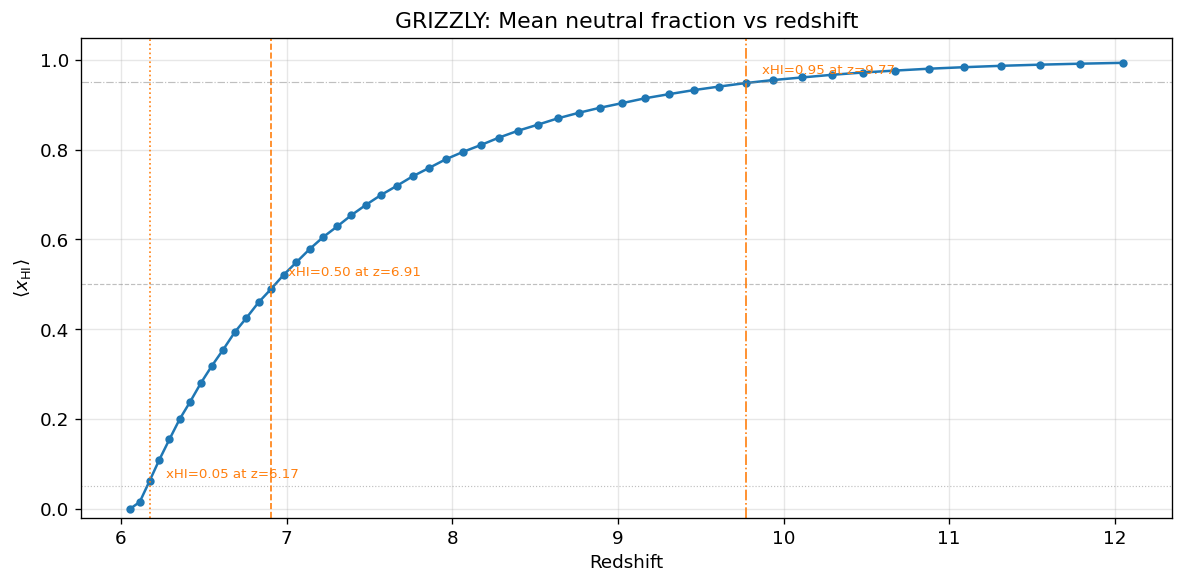


EoR range: z = 6.172 (xHI=0.05) to z = 9.771 (xHI=0.95)


In [5]:
# ── Plot mean xHI vs redshift ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(redshifts_all, mean_xHI_all, "C0o-", lw=1.5, ms=4)
ax.set_xlabel("Redshift")
ax.set_ylabel(r"$\langle x_{\rm HI} \rangle$")
ax.set_title("GRIZZLY: Mean neutral fraction vs redshift")

for thresh, ls in [(0.05, ":"), (0.5, "--"), (0.95, "-.")]:
    idx = np.argmin(np.abs(mean_xHI_all - thresh))
    ax.axhline(thresh, color="gray", ls=ls, lw=0.7, alpha=0.5)
    ax.axvline(redshifts_all[idx], color="C1", ls=ls, lw=1)
    ax.text(redshifts_all[idx] + 0.1, thresh + 0.02,
            f"xHI={thresh:.2f} at z={redshifts_all[idx]:.2f}", fontsize=8, color="C1")

ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# EoR boundaries
z_xHI_05 = redshifts_all[np.argmin(np.abs(mean_xHI_all - 0.05))]
z_xHI_95 = redshifts_all[np.argmin(np.abs(mean_xHI_all - 0.95))]
print(f"\nEoR range: z = {z_xHI_05:.3f} (xHI=0.05) to z = {z_xHI_95:.3f} (xHI=0.95)")

## 2. Stitch coeval boxes into pseudo-lightcone and compute kSZ

For each redshift snapshot, we take a slab of LOS slices proportional to the comoving
distance interval, then stack them to build a pseudo-lightcone. We compute kSZ by
summing the integrand `x_e * (1+δ) * v_z` weighted by the appropriate prefactor per slice.

In [6]:
# ── Physical constants for kSZ ──
_SIGMA_T   = 6.6524587158e-25   # Thomson cross-section [cm²]
_C_CM_S    = 2.99792458e10      # speed of light [cm/s]
_T_CMB     = 2.725e6            # CMB temperature [µK]
_M_P       = 1.6726219e-24      # proton mass [g]
_MPC_TO_CM = 3.085677581e24     # Mpc → cm


def compute_ksz_simple_grizzly(vz_cm_s, xhi, den, z, box_len_mpc, n_cells_los):
    """Compute kSZ map from a single GRIZZLY coeval box.
    
    ΔT_kSZ = -T_CMB * σ_T * n_e(z) * dl * Σ[ x_e * (1+δ) * v_z/c ]
    
    vz_cm_s: velocity in cm/s
    den: density (rho/rho_bar)
    Returns: 2D kSZ map in µK.
    """
    Y_He = 0.24
    rho_crit_0 = 1.8788e-29 * H_LITTLE**2
    rho_b_0 = OMEGA_B * rho_crit_0
    n_e_0 = rho_b_0 / _M_P * (1.0 + (1.0 - Y_He)) / 2.0
    
    n_e_z = n_e_0 * (1.0 + z)**3
    dl_cm = (box_len_mpc / (1.0 + z)) / n_cells_los * _MPC_TO_CM
    
    # Prefactor: -T_CMB * σ_T * n_e * dl  (no /c here — v/c is in integrand)
    pref = -_T_CMB * _SIGMA_T * n_e_z * dl_cm
    
    delta = den / den.mean() - 1.0
    x_e = 1.0 - np.clip(xhi, 0.0, 1.0)
    
    integrand = x_e * (1.0 + delta) * (vz_cm_s / _C_CM_S)
    ksz_map = pref * np.sum(integrand, axis=2)
    return ksz_map.astype(np.float32)


print("kSZ functions defined.")

kSZ functions defined.


In [7]:
# ── Process ALL coeval boxes and track per-snapshot stats ──
from scipy import stats

griz_results = []
ksz_eor = None
ksz_late = None

for i_z, z in enumerate(redshifts_all):
    den_full = read_den(DATA_DIR + f"{z:.3f}n_all.dat")
    xhi = read_xhi(DATA_DIR + f"{z:.3f}{XHI_PATTERN}")[CROP, CROP, CROP]
    vz = read_vel(z, den_full, DATA_DIR + f"{z:.3f}v_all.dat")[CROP, CROP, CROP]
    den = den_full[CROP, CROP, CROP]
    del den_full
    
    mean_xhi = xhi.mean()
    ksz_z = compute_ksz_simple_grizzly(vz, xhi, den, z, BOX_CROP, N_CROP)
    
    # Per-snapshot statistics
    flat = (ksz_z - ksz_z.mean()).ravel().astype(np.float64)
    sigma = flat.std()
    skew = stats.skew(flat)
    kurt = stats.kurtosis(flat)
    
    griz_results.append({
        'z': z, 'mean_xHI': mean_xhi,
        'std': sigma, 'skewness': skew, 'kurtosis': kurt,
        'ksz_map': ksz_z,
    })
    print(f"  z={z:.3f}, <xHI>={mean_xhi:.3f}, std={sigma:.4e} µK, skew={skew:.3f}")
    
    # Accumulate stitched maps
    if mean_xhi >= 0.05 and mean_xhi <= 0.95:
        if ksz_eor is None:
            ksz_eor = ksz_z.copy()
        else:
            ksz_eor += ksz_z
    elif mean_xhi < 0.05:
        if ksz_late is None:
            ksz_late = ksz_z.copy()
        else:
            ksz_late += ksz_z
    
    del den, xhi, vz
    gc.collect()

print(f"\nDone: {len(griz_results)} snapshots processed.")
if ksz_eor is not None:
    print(f"Stitched EoR kSZ: std = {ksz_eor.std():.4e} µK")
if ksz_late is not None:
    print(f"Stitched post-EoR kSZ: std = {ksz_late.std():.4e} µK")
else:
    # Use lowest-z box with forced xHI=0 as proxy
    r0 = griz_results[0]
    ksz_late = r0['ksz_map'].copy()
    print(f"No post-EoR snapshots; using z={r0['z']:.3f} as proxy")

  z=6.056, <xHI>=0.000, std=1.7370e+00 µK, skew=-0.090
  z=6.113, <xHI>=0.018, std=1.7754e+00 µK, skew=-0.063
  z=6.172, <xHI>=0.068, std=1.8633e+00 µK, skew=-0.035
  z=6.231, <xHI>=0.116, std=1.9417e+00 µK, skew=-0.053
  z=6.292, <xHI>=0.162, std=1.9959e+00 µK, skew=-0.066
  z=6.354, <xHI>=0.207, std=2.0366e+00 µK, skew=-0.070
  z=6.418, <xHI>=0.246, std=2.0627e+00 µK, skew=-0.068
  z=6.483, <xHI>=0.288, std=2.0770e+00 µK, skew=-0.061
  z=6.549, <xHI>=0.326, std=2.0828e+00 µK, skew=-0.051
  z=6.617, <xHI>=0.362, std=2.0814e+00 µK, skew=-0.044
  z=6.686, <xHI>=0.400, std=2.0731e+00 µK, skew=-0.039
  z=6.757, <xHI>=0.431, std=2.0634e+00 µK, skew=-0.033
  z=6.830, <xHI>=0.466, std=2.0457e+00 µK, skew=-0.027
  z=6.905, <xHI>=0.495, std=2.0271e+00 µK, skew=-0.022
  z=6.981, <xHI>=0.526, std=2.0000e+00 µK, skew=-0.016
  z=7.059, <xHI>=0.554, std=1.9713e+00 µK, skew=-0.011
  z=7.139, <xHI>=0.584, std=1.9379e+00 µK, skew=-0.006
  z=7.221, <xHI>=0.610, std=1.9012e+00 µK, skew=-0.001
  z=7.305,

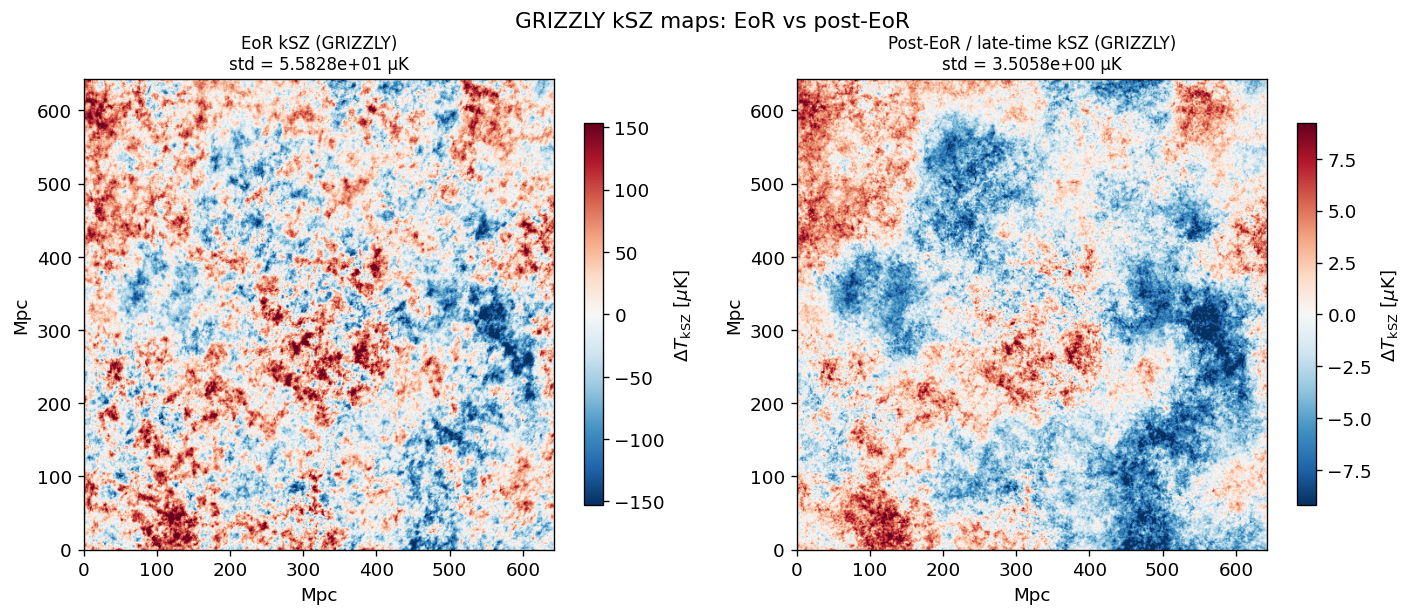

In [8]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (m, label) in zip(axes, [
    (ksz_eor, "EoR kSZ (GRIZZLY)"),
    (ksz_late, "Post-EoR / late-time kSZ (GRIZZLY)"),
]):
    vmax = np.percentile(np.abs(m), 99)
    if vmax == 0:
        vmax = 1
    im = ax.imshow(m, cmap="RdBu_r", origin="lower",
                   extent=[0, BOX_CROP, 0, BOX_CROP], vmin=-vmax, vmax=vmax)
    ax.set_title(f"{label}\nstd = {m.std():.4e} µK", fontsize=10)
    ax.set_xlabel("Mpc"); ax.set_ylabel("Mpc")
    plt.colorbar(im, ax=ax, label=r"$\Delta T_{\rm kSZ}$ [$\mu$K]", shrink=0.8)

plt.suptitle("GRIZZLY kSZ maps: EoR vs post-EoR", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Non-Gaussianity diagnostics

In [9]:
# ── Pixel statistics ──

def pixel_statistics(map_2d, label=""):
    flat = map_2d.ravel().astype(np.float64)
    flat = flat - flat.mean()
    sigma = flat.std()
    skew = stats.skew(flat)
    kurt = stats.kurtosis(flat)
    m5 = np.mean((flat / sigma)**5)
    m6 = np.mean((flat / sigma)**6) - 15
    n_sw = min(5000, len(flat))
    _, p_shapiro = stats.shapiro(np.random.choice(flat, n_sw, replace=False))
    _, p_dagostino = stats.normaltest(flat)
    result = {
        "label": label, "std": sigma, "skewness": skew,
        "excess_kurtosis": kurt, "m5 (5th moment)": m5,
        "m6_excess (6th moment - 15)": m6,
        "p_shapiro": p_shapiro, "p_dagostino": p_dagostino,
    }
    print(f"── {label} ──")
    print(f"  std         = {sigma:.4e}")
    print(f"  skewness    = {skew:.4f}   (Gaussian = 0)")
    print(f"  ex. kurtosis= {kurt:.4f}   (Gaussian = 0)")
    print(f"  m5          = {m5:.4f}   (Gaussian = 0)")
    print(f"  m6 excess   = {m6:.4f}   (Gaussian = 0)")
    print(f"  Shapiro p   = {p_shapiro:.2e}")
    print(f"  D'Agostino p= {p_dagostino:.2e}")
    return result


ksz_maps = {
    "EoR kSZ (GRIZZLY)": ksz_eor,
    "Post-EoR kSZ (GRIZZLY)": ksz_late,
}

all_stats = {}
for label, m in ksz_maps.items():
    all_stats[label] = pixel_statistics(m, label=label)
    print()

── EoR kSZ (GRIZZLY) ──
  std         = 5.5828e+01
  skewness    = -0.0175   (Gaussian = 0)
  ex. kurtosis= 0.4089   (Gaussian = 0)
  m5          = -0.1934   (Gaussian = 0)
  m6 excess   = 6.2755   (Gaussian = 0)
  Shapiro p   = 3.18e-07
  D'Agostino p= 2.89e-311

── Post-EoR kSZ (GRIZZLY) ──
  std         = 3.5058e+00
  skewness    = -0.0781   (Gaussian = 0)
  ex. kurtosis= -0.1383   (Gaussian = 0)
  m5          = -0.5146   (Gaussian = 0)
  m6 excess   = -1.8760   (Gaussian = 0)
  Shapiro p   = 2.66e-04
  D'Agostino p= 3.43e-123



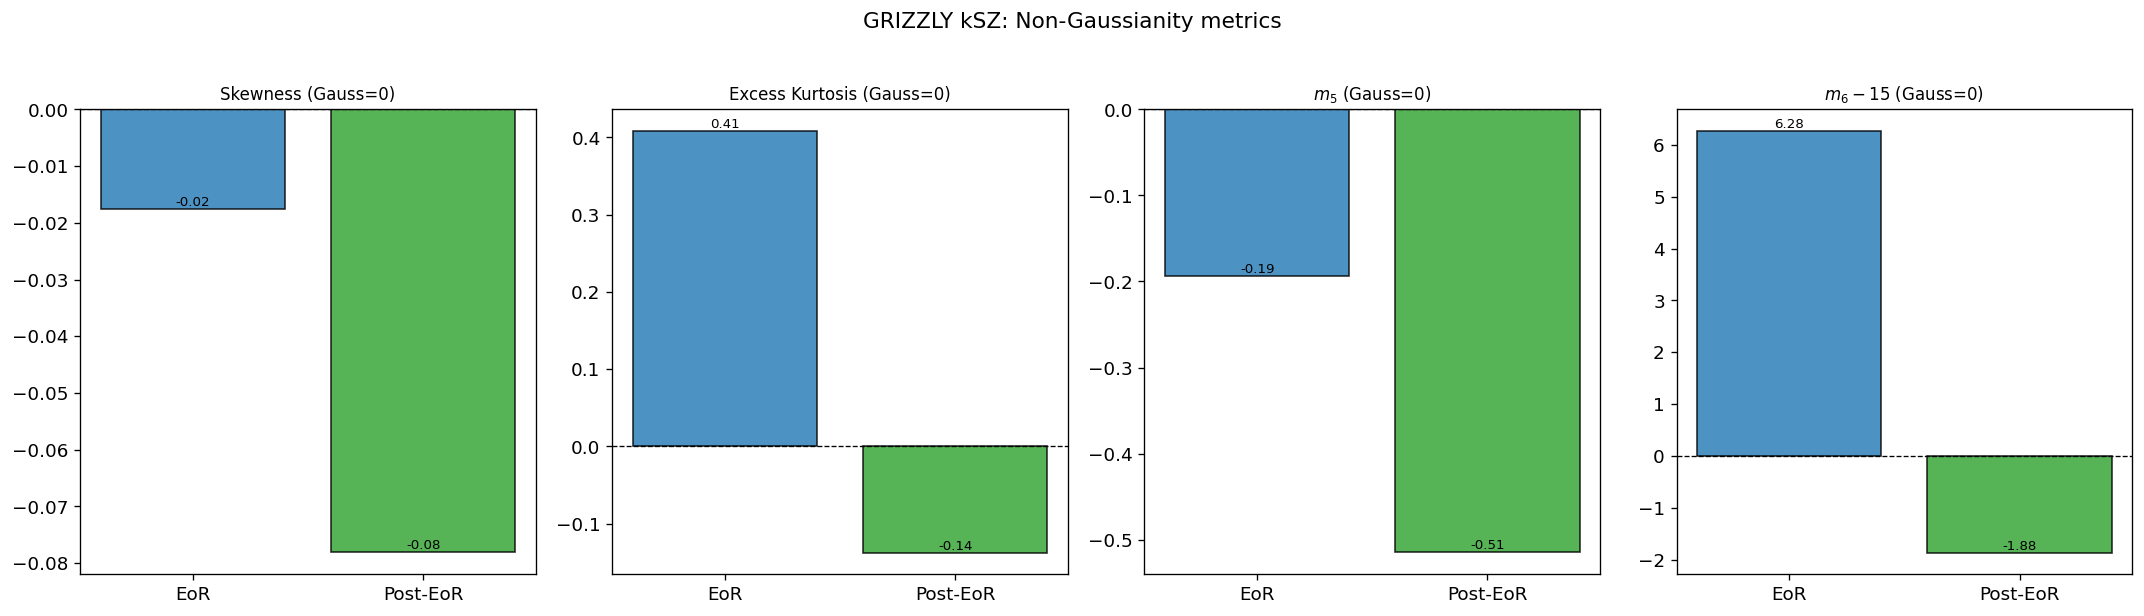

In [10]:
# ── Bar chart ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

labels = list(all_stats.keys())
colors = ["C0", "C2"]
metrics = [
    ("skewness", "Skewness"),
    ("excess_kurtosis", "Excess Kurtosis"),
    ("m5 (5th moment)", r"$m_5$"),
    ("m6_excess (6th moment - 15)", r"$m_6 - 15$"),
]

for ax, (key, title) in zip(axes, metrics):
    vals = [all_stats[l][key] for l in labels]
    bars = ax.bar(["EoR", "Post-EoR"], vals, color=colors, edgecolor="k", alpha=0.8)
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_title(f"{title} (Gauss=0)", fontsize=10)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("GRIZZLY kSZ: Non-Gaussianity metrics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

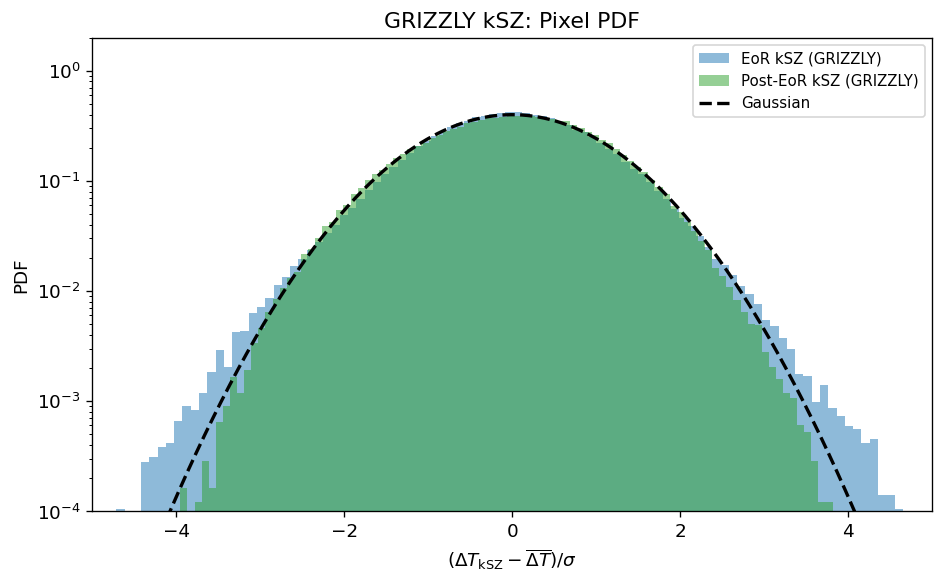

In [11]:
# ── Pixel PDF ──
fig, ax = plt.subplots(figsize=(8, 5))

for (label, m), color in zip(ksz_maps.items(), ["C0", "C2"]):
    flat = m.ravel().astype(np.float64)
    flat = (flat - flat.mean()) / flat.std()
    ax.hist(flat, bins=100, density=True, alpha=0.5, label=label,
            histtype="stepfilled", color=color)

x = np.linspace(-5, 5, 300)
ax.plot(x, stats.norm.pdf(x), "k--", lw=2, label="Gaussian")
ax.set_xlabel(r"$(\Delta T_{\rm kSZ} - \overline{\Delta T}) / \sigma$")
ax.set_ylabel("PDF")
ax.set_yscale("log")
ax.set_ylim(1e-4, 2)
ax.set_xlim(-5, 5)
ax.legend(fontsize=9)
ax.set_title("GRIZZLY kSZ: Pixel PDF")
plt.tight_layout()
plt.show()

## 4. Minkowski functionals

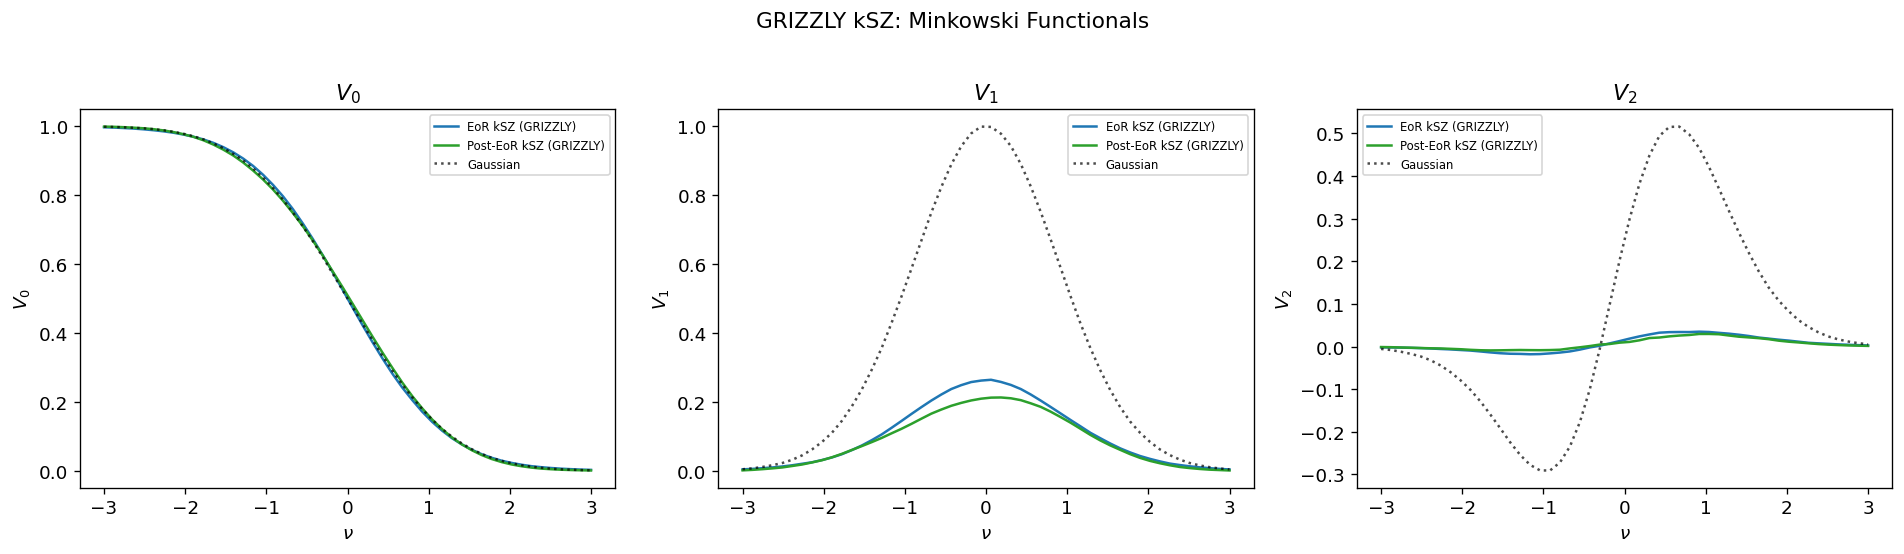

In [ ]:
# def minkowski_functionals_2d(map_2d, n_thresholds=50):
#     flat = map_2d.astype(np.float64)
#     mu, sigma = flat.mean(), flat.std()
#     nu = np.linspace(-3, 3, n_thresholds)
#     thresholds = mu + nu * sigma
#     V0 = np.zeros(n_thresholds)
#     V1 = np.zeros(n_thresholds)
#     V2 = np.zeros(n_thresholds)
#     ny, nx = map_2d.shape
#     for i, thr in enumerate(thresholds):
#         binary = (map_2d > thr).astype(np.int8)
#         V0[i] = binary.mean()
#         V1[i] = (np.abs(np.diff(binary, axis=1)).sum() + np.abs(np.diff(binary, axis=0)).sum()) / (nx * ny)
#         c1, c2, c3, c4 = binary[:-1, :-1], binary[:-1, 1:], binary[1:, :-1], binary[1:, 1:]
#         s = c1 + c2 + c3 + c4
#         n1 = np.sum(s == 1); n3 = np.sum(s == 3)
#         diag_a = np.sum((c1 == 1) & (c4 == 1) & (c2 == 0) & (c3 == 0))
#         diag_b = np.sum((c2 == 1) & (c3 == 1) & (c1 == 0) & (c4 == 0))
#         V2[i] = (n1 - n3 + 2 * (diag_a + diag_b)) / ((nx - 1) * (ny - 1))
#     return nu, V0, V1, V2


# fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# for (label, m), color in zip(ksz_maps.items(), ["C0", "C2"]):
#     nu, V0, V1, V2 = minkowski_functionals_2d(m)
#     axes[0].plot(nu, V0, color=color, label=label, lw=1.5)
#     axes[1].plot(nu, V1, color=color, label=label, lw=1.5)
#     axes[2].plot(nu, V2, color=color, label=label, lw=1.5)

# gauss_map = np.random.randn(N_CROP, N_CROP).astype(np.float32)
# nu_g, V0g, V1g, V2g = minkowski_functionals_2d(gauss_map)
# for ax, Vg in zip(axes, [V0g, V1g, V2g]):
#     ax.plot(nu_g, Vg, "k:", lw=1.5, alpha=0.7, label="Gaussian")

# titles = [r"$V_0$", r"$V_1$", r"$V_2$"]
# for ax, title in zip(axes, titles):
#     ax.set_xlabel(r"$\nu$"); ax.set_ylabel(title); ax.set_title(title)
#     ax.legend(fontsize=7)

# plt.suptitle("GRIZZLY kSZ: Minkowski Functionals", fontsize=13, y=1.02)
# plt.tight_layout()
# plt.show()

## 5. Power spectra

/Users/jelte/Documents/PhD/noise_analysis/.venv/lib/python3.11/site-packages/powerbox/tools.py:307: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


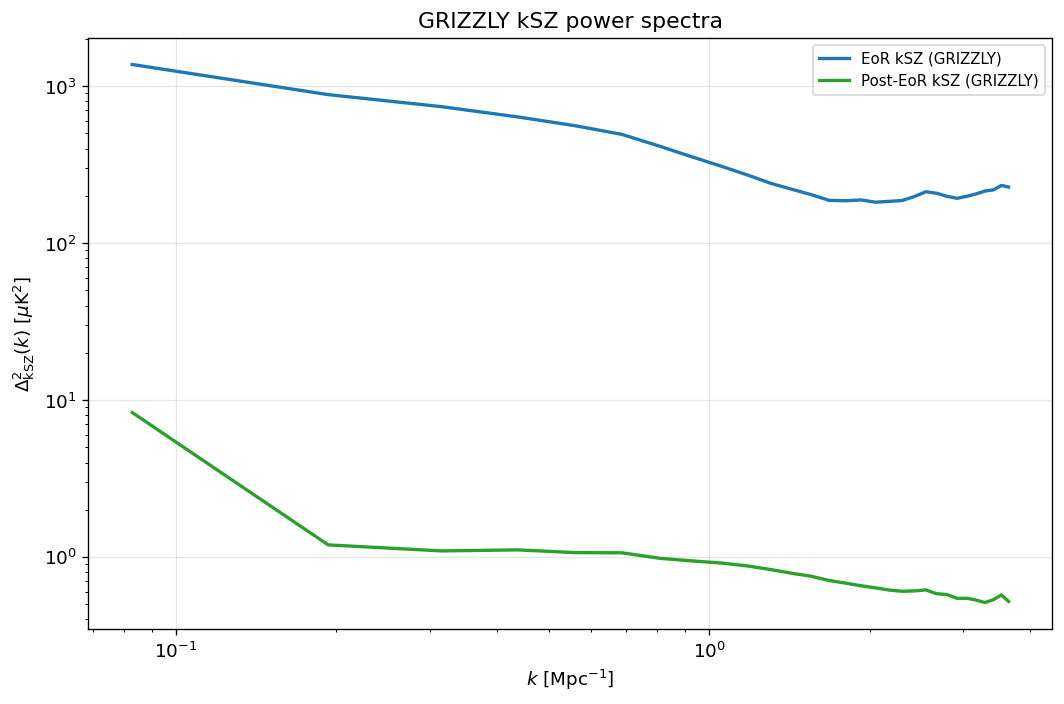

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for (label, m), color in zip(ksz_maps.items(), ["C0", "C2"]):
    m_zero = (m - m.mean()).astype(np.float64)
    P, k, *_ = get_power(m_zero, boxlength=[BOX_CROP, BOX_CROP], bins=30,
                          ignore_zero_mode=True, dimensionless=False)
    ax.loglog(k, P * k**2 / (2 * np.pi), color=color, lw=2, label=label)

ax.set_xlabel(r"$k$ [Mpc$^{-1}$]")
ax.set_ylabel(r"$\Delta^2_{\rm kSZ}(k)$ [$\mu$K$^2$]")
ax.set_title("GRIZZLY kSZ power spectra")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Bispectrum (BFast)

In [14]:
# ── Bispectrum using BFast ──

def compute_bispectrum_bfast(map_2d, box_len, n_bins=15):
    field = jnp.array((map_2d - map_2d.mean()).astype(np.float32))
    nx = map_2d.shape[0]
    bin_edges = jnp.arange(1, nx // 3, max(1, nx // (3 * n_bins)))
    result = BFast.Bk(field, boxsize=box_len, bin_edges=bin_edges, fast=True, jit=True)
    Bk = np.array(result['Bk'])
    tri = np.array(result['triangle_centers'])
    k_max = np.max(tri, axis=1)
    k_min = np.min(tri, axis=1)
    squeeze = k_min / np.maximum(k_max, 1e-10)
    eq_mask = squeeze > 0.95
    sq_mask = squeeze < 0.25
    return {
        'Bk': Bk, 'triangles': tri, 'squeeze': squeeze, 'k_max': k_max,
        'eq_mask': eq_mask, 'sq_mask': sq_mask,
        'k_eq': tri[:, 0][eq_mask], 'Bk_eq': Bk[eq_mask],
        'k_sq': k_max[sq_mask], 'Bk_sq': Bk[sq_mask],
    }

print("Computing bispectrum with BFast...")
bispec_results = {}
for label, m in ksz_maps.items():
    print(f"  {label}...", end=" ", flush=True)
    bispec_results[label] = compute_bispectrum_bfast(m, BOX_CROP)
    print(f"done ({bispec_results[label]['Bk'].shape[0]} triangles)")

Computing bispectrum with BFast...
  EoR kSZ (GRIZZLY)... done (399 triangles)
  Post-EoR kSZ (GRIZZLY)... done (399 triangles)


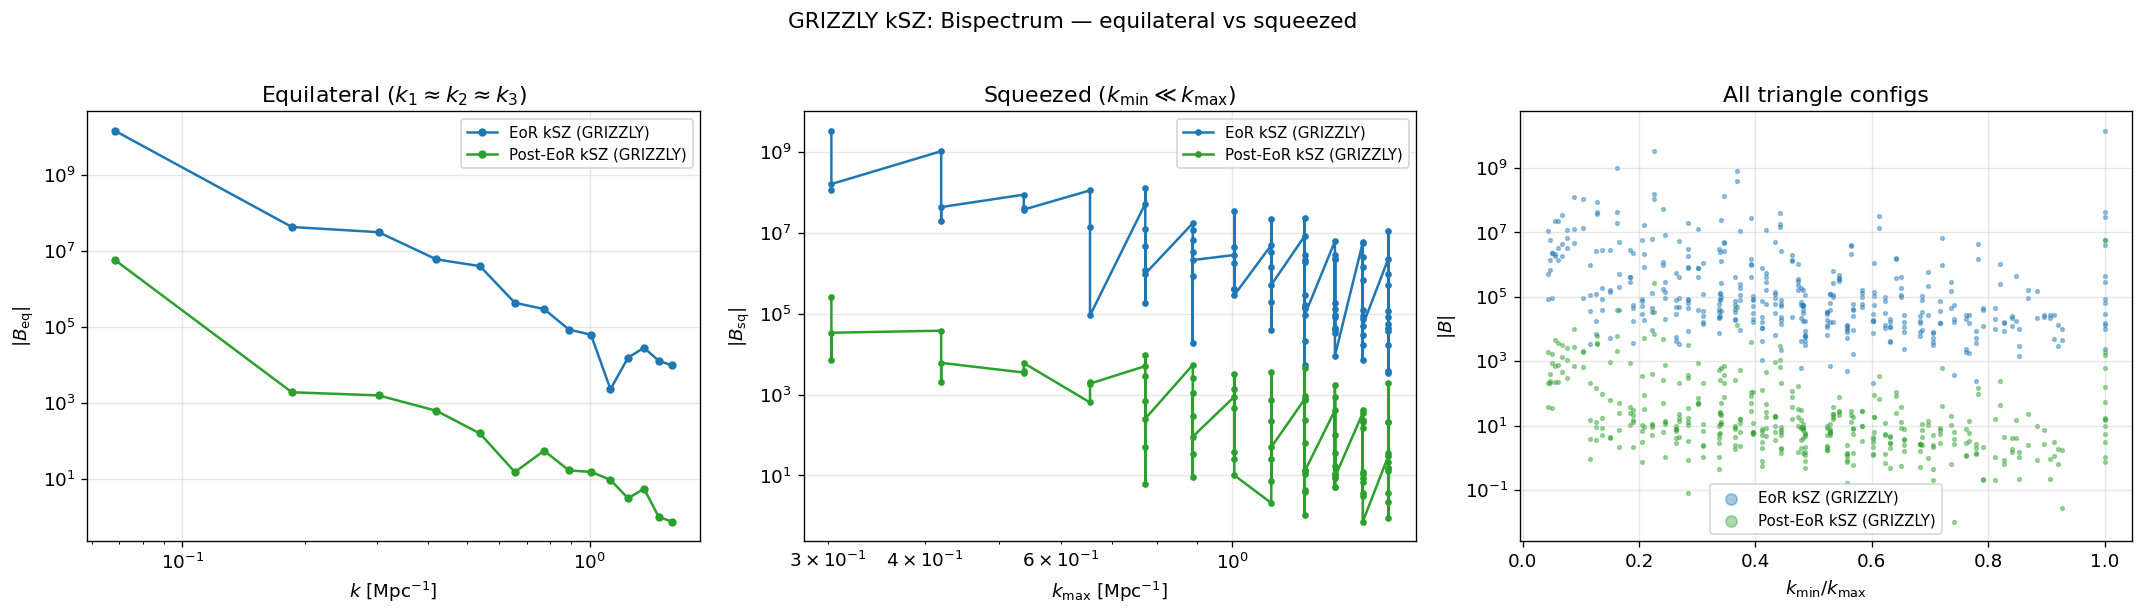

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for (label, res), color in zip(bispec_results.items(), ["C0", "C2"]):
    if res['eq_mask'].sum() > 0:
        axes[0].plot(res['k_eq'], np.abs(res['Bk_eq']), "o-", color=color, label=label, ms=4)
    if res['sq_mask'].sum() > 0:
        axes[1].plot(res['k_sq'], np.abs(res['Bk_sq']), "o-", color=color, label=label, ms=3)
    axes[2].scatter(res['squeeze'], np.abs(res['Bk']), c=color, s=5, alpha=0.4, label=label)

axes[0].set_xlabel(r"$k$ [Mpc$^{-1}$]"); axes[0].set_ylabel(r"$|B_{\rm eq}|$")
axes[0].set_title(r"Equilateral ($k_1 \approx k_2 \approx k_3$)")
axes[0].set_yscale("log"); axes[0].set_xscale("log")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r"$k_{\rm max}$ [Mpc$^{-1}$]"); axes[1].set_ylabel(r"$|B_{\rm sq}|$")
axes[1].set_title(r"Squeezed ($k_{\rm min} \ll k_{\rm max}$)")
axes[1].set_yscale("log"); axes[1].set_xscale("log")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel(r"$k_{\rm min}/k_{\rm max}$"); axes[2].set_ylabel(r"$|B|$")
axes[2].set_title("All triangle configs"); axes[2].set_yscale("log")
axes[2].legend(fontsize=9, markerscale=3); axes[2].grid(True, alpha=0.3)

plt.suptitle("GRIZZLY kSZ: Bispectrum — equilateral vs squeezed", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary: kSZ amplitude and non-Gaussianity vs EoR stage

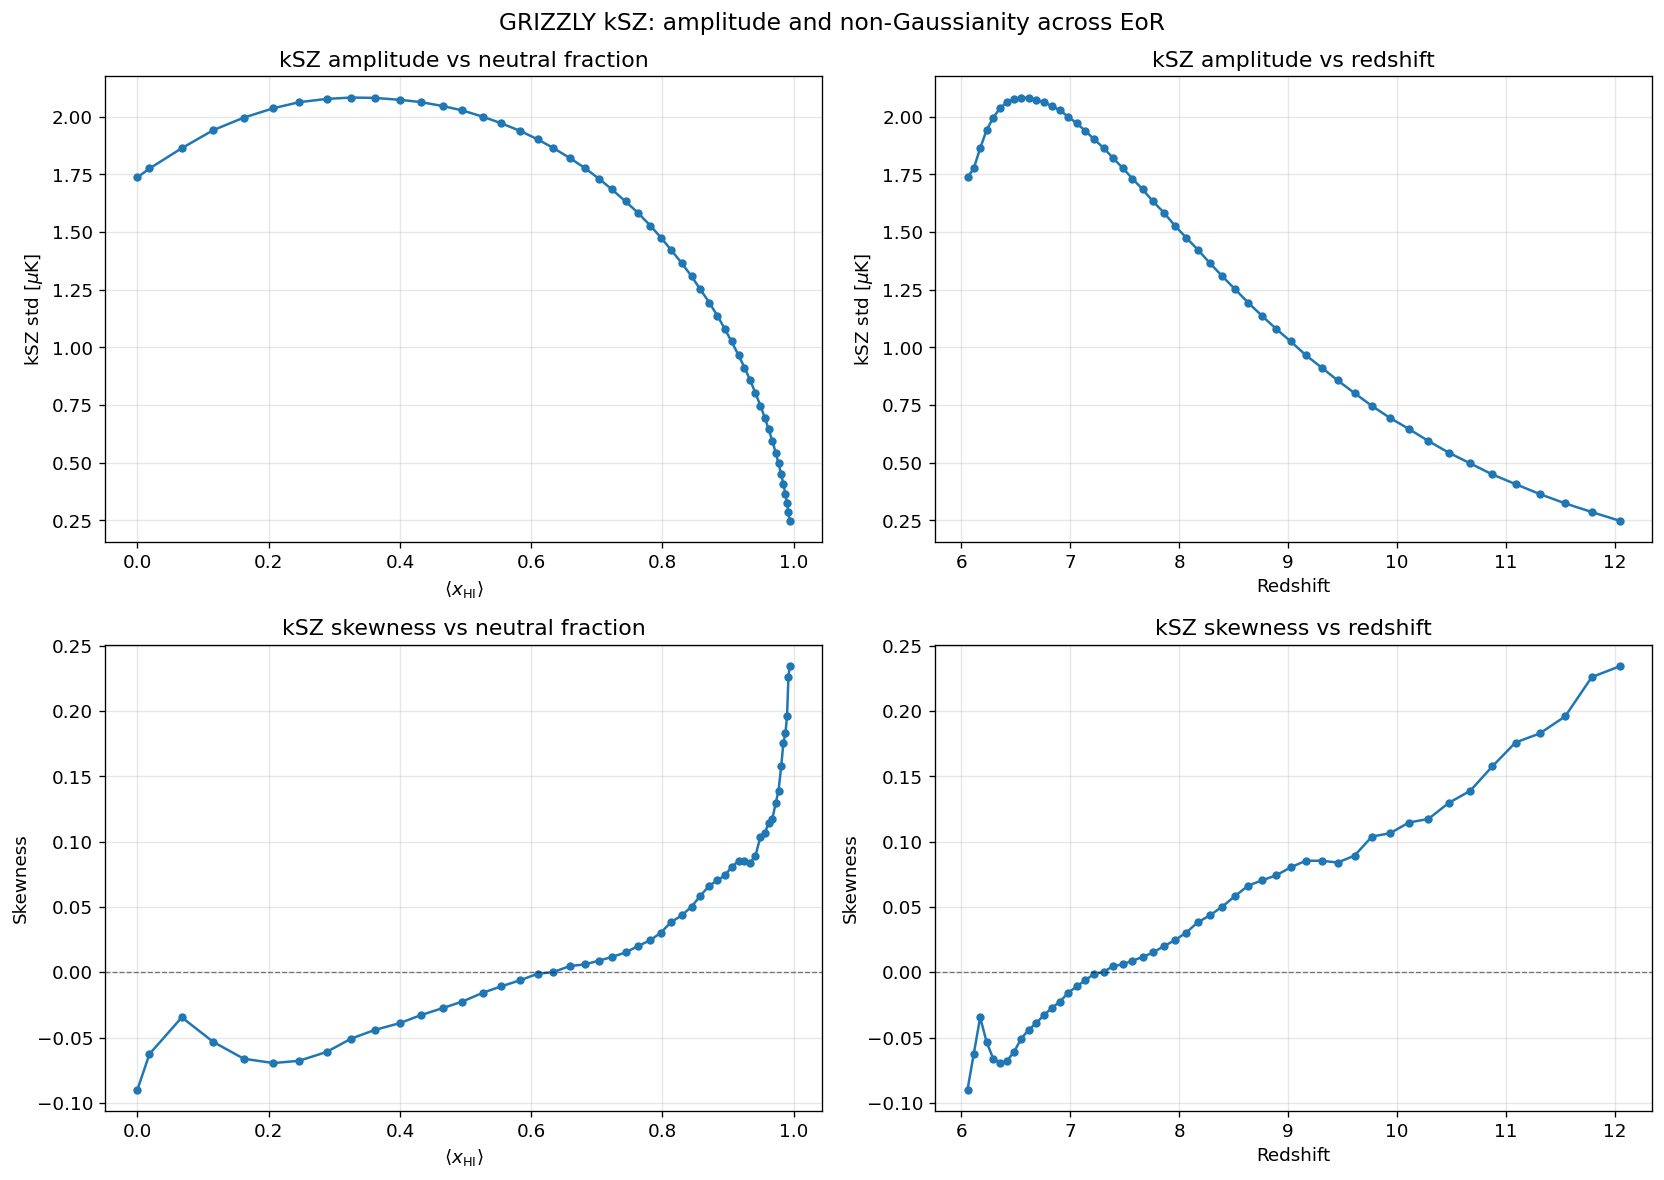

      z |  <xHI> |   kSZ std [µK] |  skewness |  kurtosis
----------------------------------------------------------
  6.056 |  0.000 |     1.7370e+00 |    -0.090 |    -0.129
  6.113 |  0.018 |     1.7754e+00 |    -0.063 |    -0.150
  6.172 |  0.068 |     1.8633e+00 |    -0.035 |     0.031
  6.231 |  0.116 |     1.9417e+00 |    -0.053 |     0.112
  6.292 |  0.162 |     1.9959e+00 |    -0.066 |     0.201
  6.354 |  0.207 |     2.0366e+00 |    -0.070 |     0.246
  6.418 |  0.246 |     2.0627e+00 |    -0.068 |     0.253
  6.483 |  0.288 |     2.0770e+00 |    -0.061 |     0.252
  6.549 |  0.326 |     2.0828e+00 |    -0.051 |     0.260
  6.617 |  0.362 |     2.0814e+00 |    -0.044 |     0.266
  6.686 |  0.400 |     2.0731e+00 |    -0.039 |     0.274
  6.757 |  0.431 |     2.0634e+00 |    -0.033 |     0.282
  6.830 |  0.466 |     2.0457e+00 |    -0.027 |     0.291
  6.905 |  0.495 |     2.0271e+00 |    -0.022 |     0.306
  6.981 |  0.526 |     2.0000e+00 |    -0.016 |     0.320
  7.059 |  0.

In [16]:
# ── kSZ std and skewness vs xHI and redshift ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

z_arr = np.array([r['z'] for r in griz_results])
xhi_arr = np.array([r['mean_xHI'] for r in griz_results])
std_arr = np.array([r['std'] for r in griz_results])
skew_arr = np.array([r['skewness'] for r in griz_results])
kurt_arr = np.array([r['kurtosis'] for r in griz_results])

# Top-left: kSZ std vs xHI
ax = axes[0, 0]
ax.plot(xhi_arr, std_arr, 'o-', color='C0', ms=4, lw=1.5)
ax.set_xlabel(r'$\langle x_{\rm HI} \rangle$')
ax.set_ylabel(r'kSZ std [$\mu$K]')
ax.set_title('kSZ amplitude vs neutral fraction')
ax.grid(True, alpha=0.3)

# Top-right: kSZ std vs z
ax = axes[0, 1]
ax.plot(z_arr, std_arr, 'o-', color='C0', ms=4, lw=1.5)
ax.set_xlabel('Redshift')
ax.set_ylabel(r'kSZ std [$\mu$K]')
ax.set_title('kSZ amplitude vs redshift')
ax.grid(True, alpha=0.3)

# Bottom-left: skewness vs xHI
ax = axes[1, 0]
ax.plot(xhi_arr, skew_arr, 'o-', color='C0', ms=4, lw=1.5)
ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel(r'$\langle x_{\rm HI} \rangle$')
ax.set_ylabel('Skewness')
ax.set_title('kSZ skewness vs neutral fraction')
ax.grid(True, alpha=0.3)

# Bottom-right: skewness vs z
ax = axes[1, 1]
ax.plot(z_arr, skew_arr, 'o-', color='C0', ms=4, lw=1.5)
ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Redshift')
ax.set_ylabel('Skewness')
ax.set_title('kSZ skewness vs redshift')
ax.grid(True, alpha=0.3)

plt.suptitle('GRIZZLY kSZ: amplitude and non-Gaussianity across EoR', fontsize=14)
plt.tight_layout()
plt.show()

# Print table
print(f"{'z':>7s} | {'<xHI>':>6s} | {'kSZ std [µK]':>14s} | {'skewness':>9s} | {'kurtosis':>9s}")
print("-" * 58)
for r in griz_results:
    print(f"{r['z']:7.3f} | {r['mean_xHI']:6.3f} | {r['std']:14.4e} | {r['skewness']:9.3f} | {r['kurtosis']:9.3f}")